In [47]:
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt

In [48]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 20}
    plt.rc("font", **font)

In [49]:
set_style()

In [50]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [51]:
def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result

In [52]:
params_path = "params/experiment_1.json"
input_path = "results/experiment_1.pkl"
result_path = "results/experiment_1/"

In [53]:
params_global = reader(params_path)

{'data': {'sample_sizes': [500, 1000, 2000], 'feature_number': 100, 'label_number': 10, 'avg_label_number': 5, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'n_estimators_min': 10, 'n_estimators_max': 100, 'criterion': ['gini', 'entropy'], 'lam_numbers': [10, 30, 50]}, 'risk': {'control_level': 0.2}}


In [54]:
results__ = load_list_with_pickle(input_path)

In [55]:
colors = ["red", "green", "blue"]
methods = ["Split", "Oracle", "Upper"]

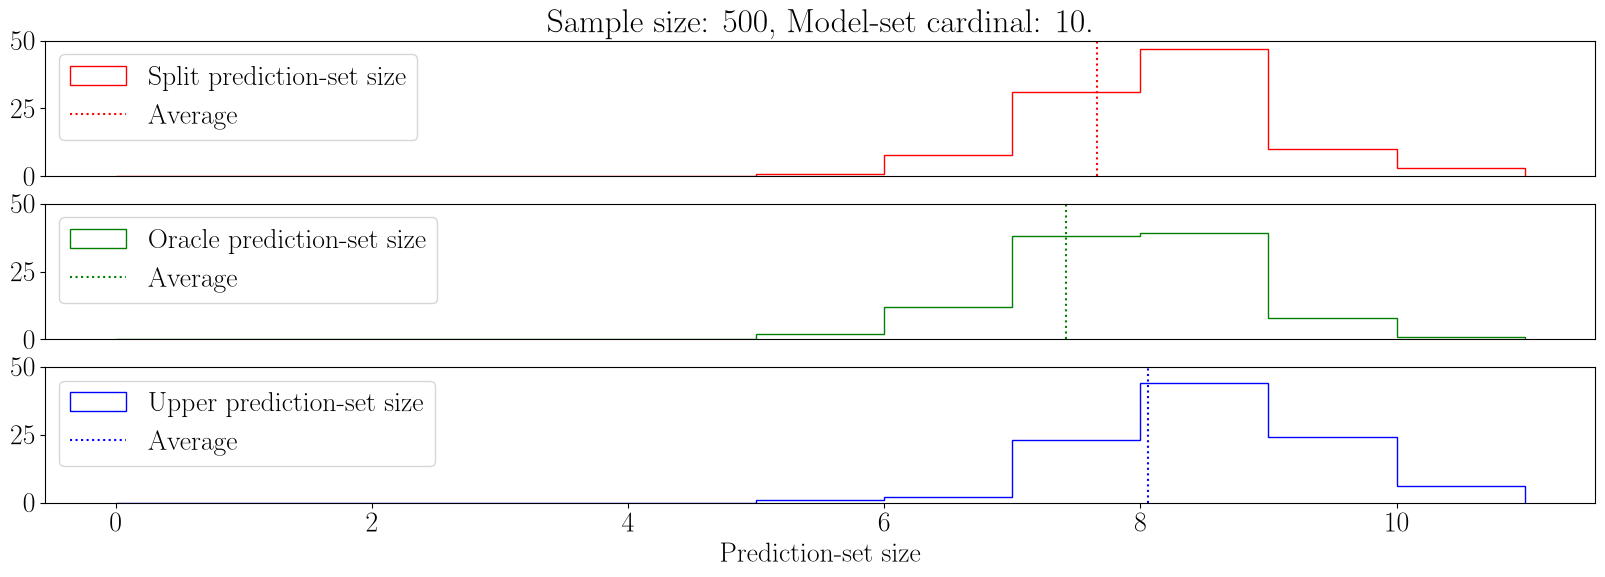

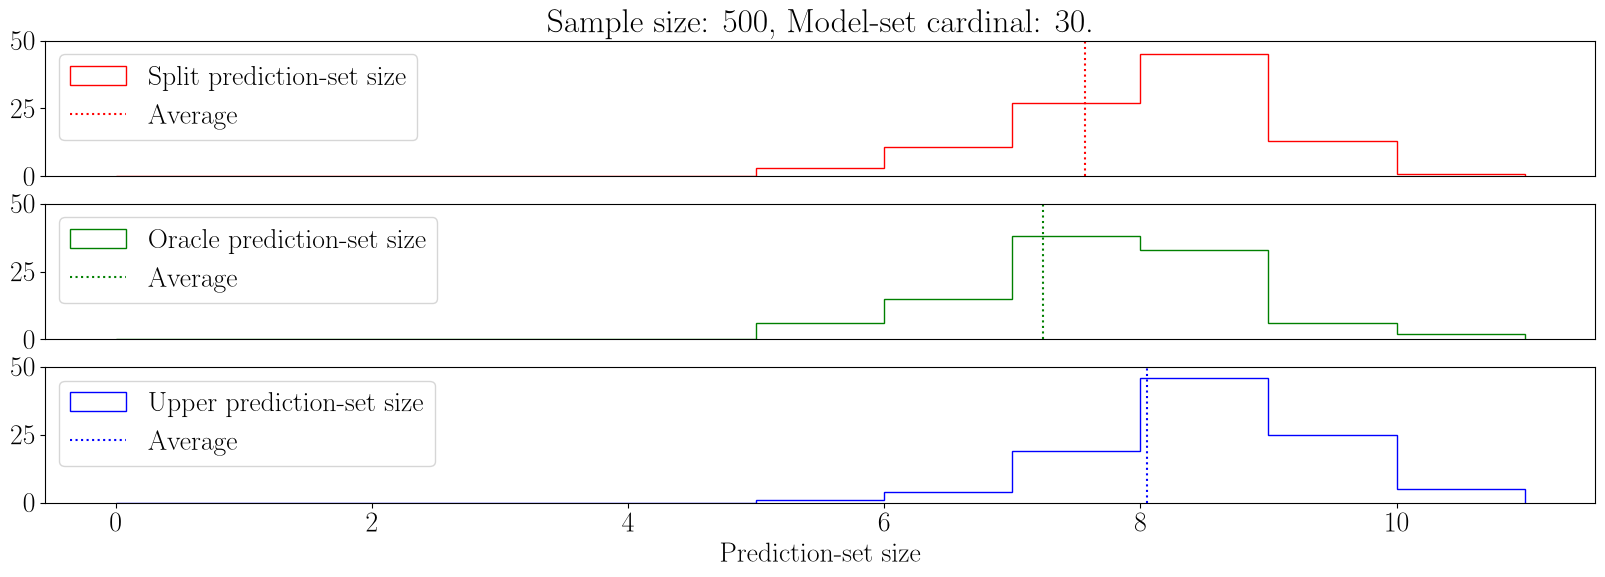

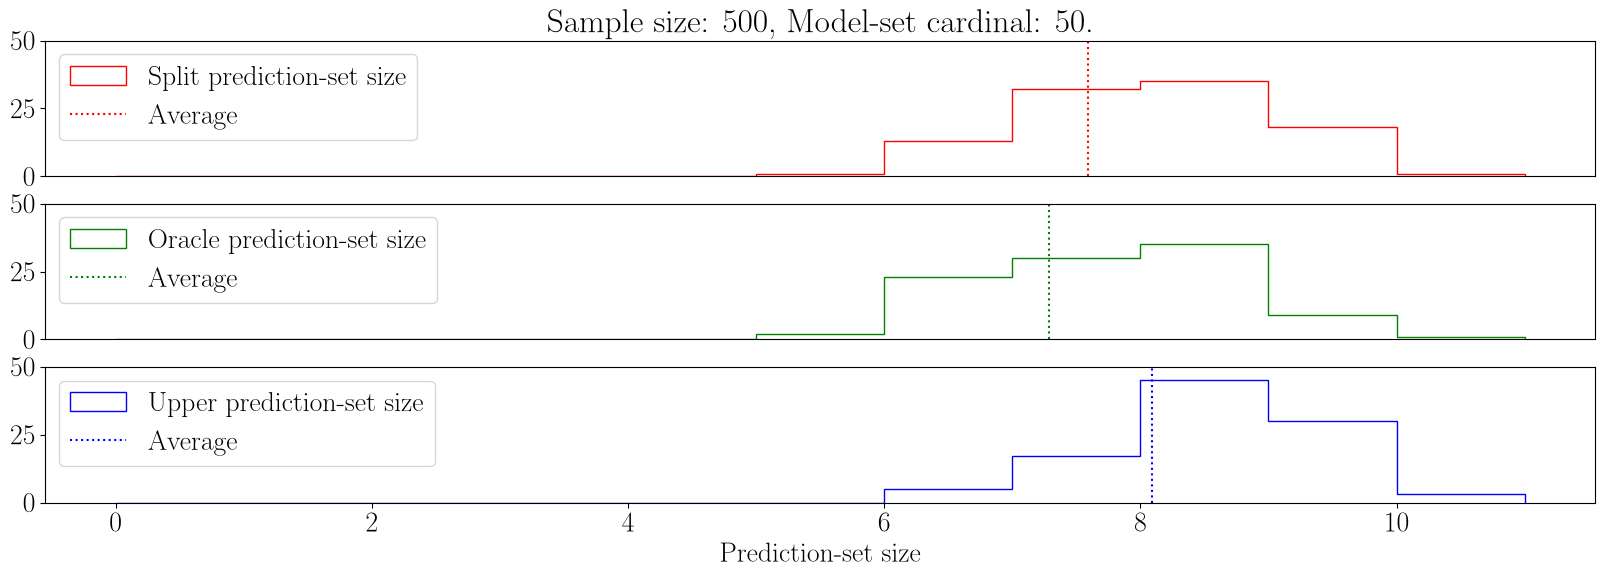

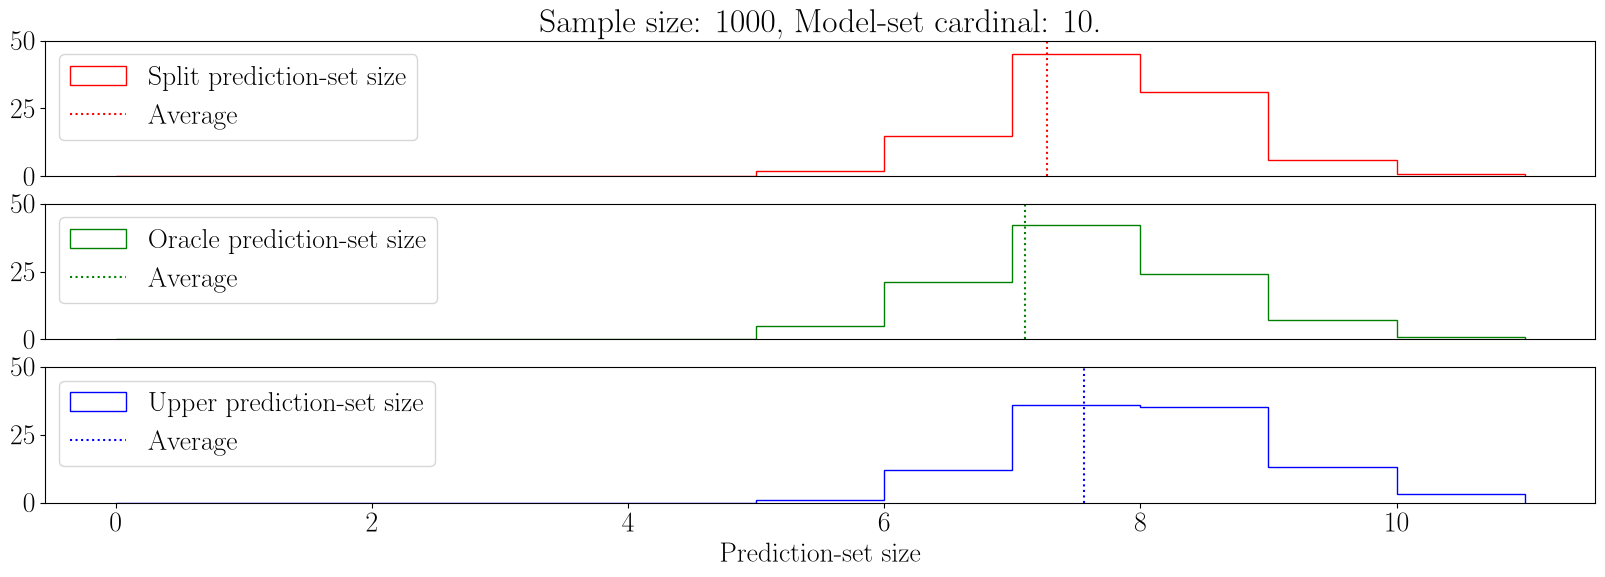

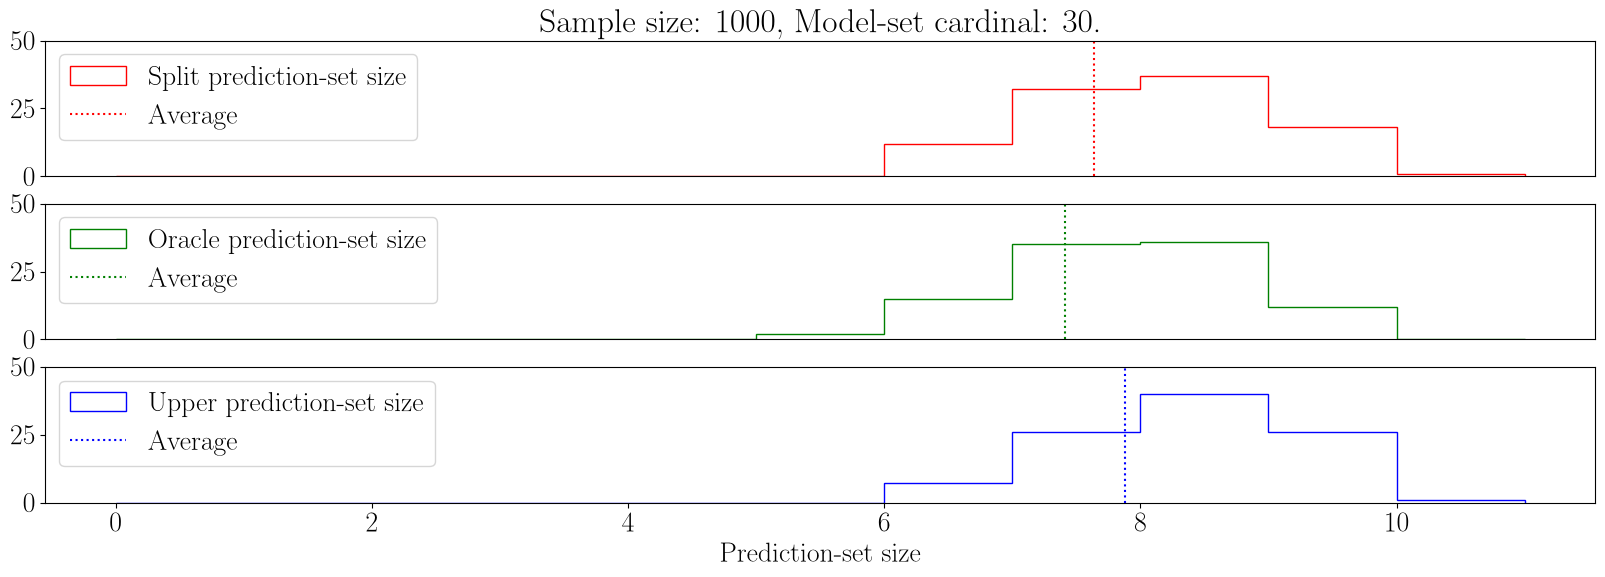

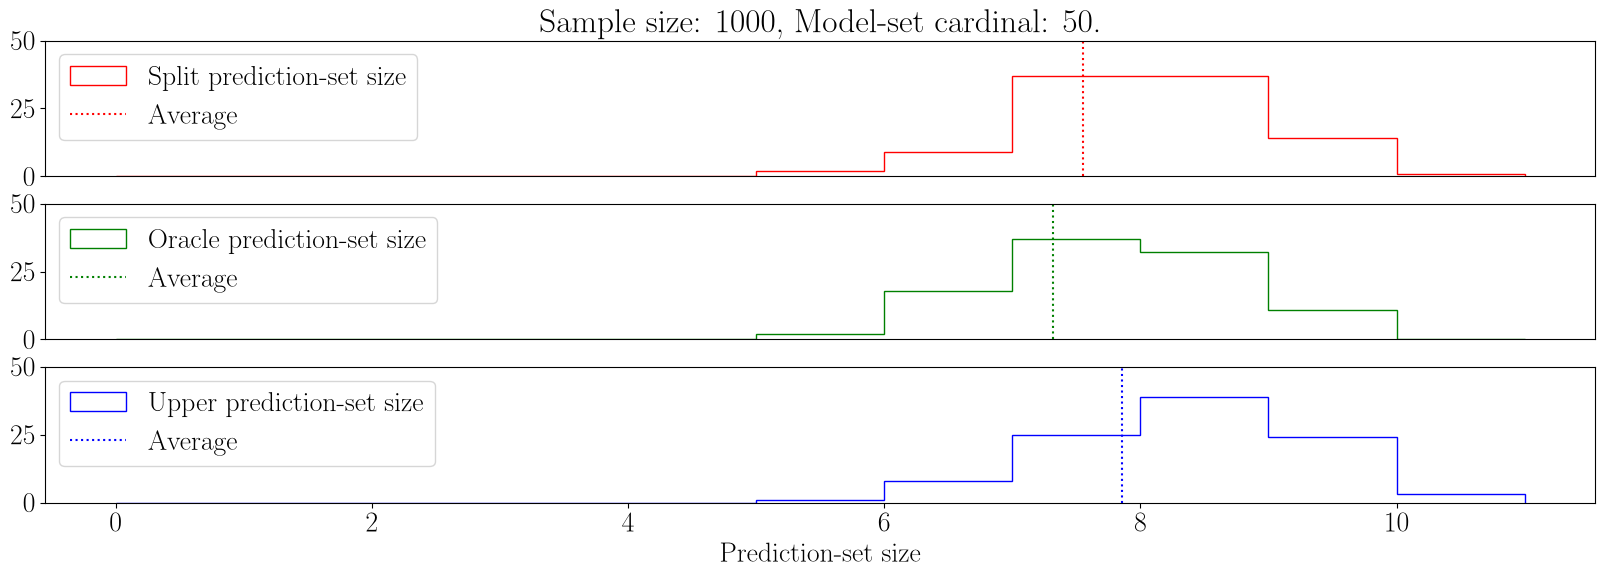

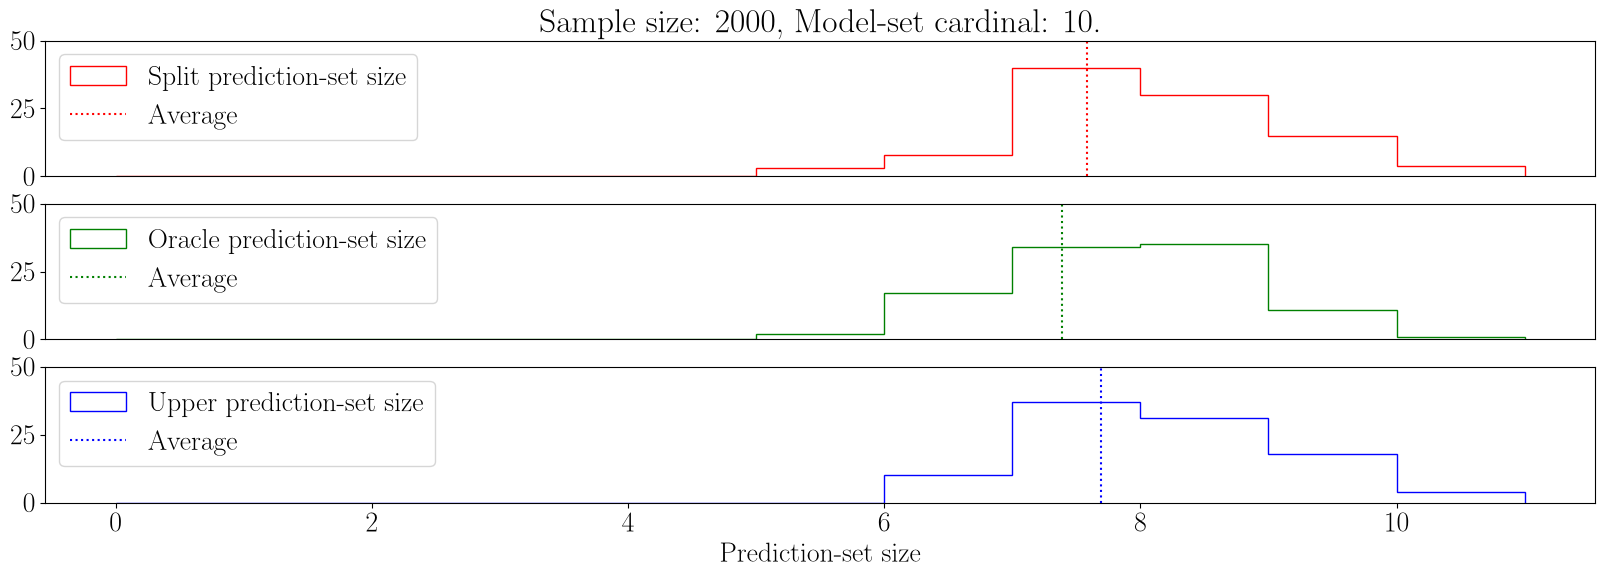

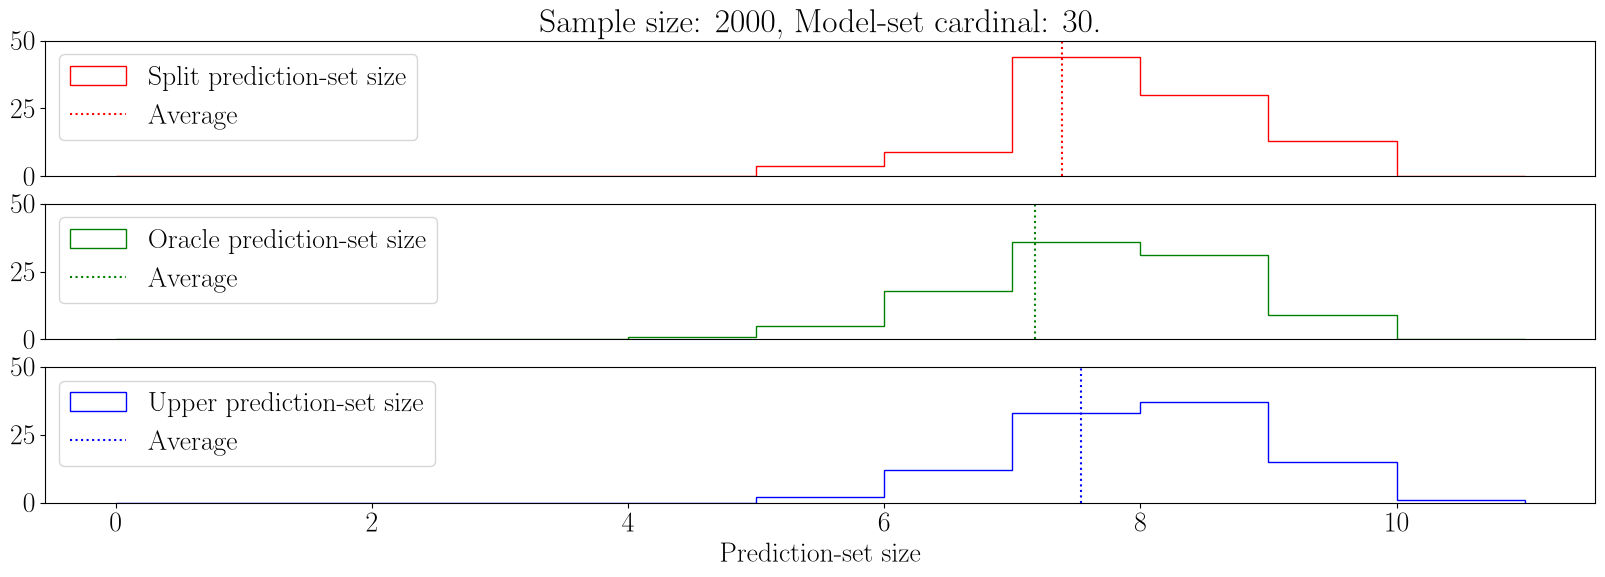

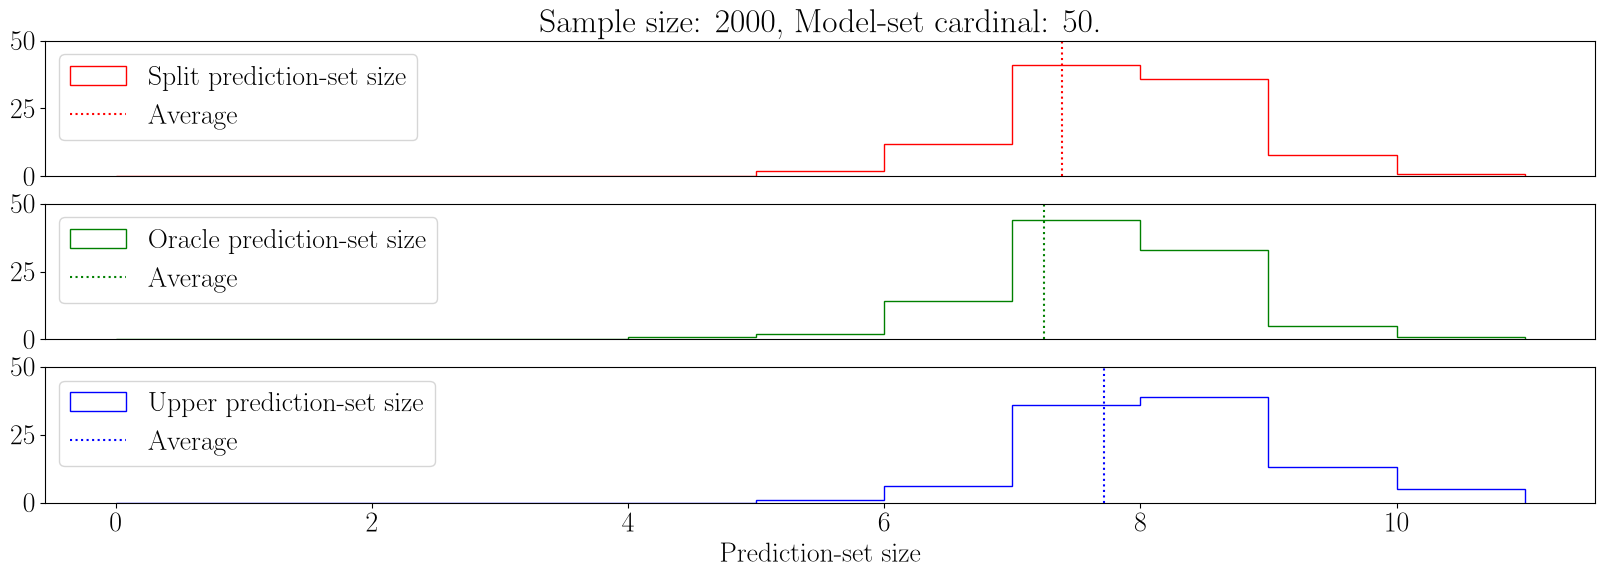

In [56]:
for results_, sample_size in zip(results__, params_global["data"]["sample_sizes"]):
    for results, lam_number in zip(results_, params_global["predictor"]["lam_numbers"]):
        fig, axs = plt.subplots(len(methods), figsize=(20, 6))
        for ax, method, color in zip(axs, methods, colors):
            average_size = np.average(results["size"][method])
            ax.hist(
                results["size"][method],
                histtype="step",
                color=color,
                label=method + " prediction-set size",
                bins=range(0, params_global["data"]["label_number"] + 2),
            )
            ax.plot(
                [average_size, average_size],
                [0, 50],
                color=color,
                linestyle="dotted",
                label="Average",
            )
            ax.set_ylim(0, 50)
            if method in ["Split"]:
                ax.set_title(
                    "Sample size: {}, Model-set cardinal: {}.".format(
                        sample_size, lam_number
                    )
                )
            if method in ["Split", "Oracle"]:
                ax.set_xticks([])
            if method in ["Upper"]:
                ax.set_xlabel("Prediction-set size")
            ax.legend(loc="upper left")

        fig.savefig(
            result_path
            + "sample_size_{}_lam_number_{}".format(sample_size, lam_number)
            + ".png",
            bbox_inches="tight",
        )